# DA6401 Assignment 1 — Neural Network Implementation and W&B Experiments

**Name:** Shlok Shetty  
**Course:** DA6401 - Deep Learning   

---

## Objective

The goal of this assignment is to:

1. Implement a fully connected neural network from scratch using NumPy.
2. Train the model on the MNIST/Fashion-MNIST dataset.
3. Perform hyperparameter tuning and experiments using **Weights & Biases (W&B)**.


Experiments are logged using **Weights & Biases** for reproducibility and visualization.


In [1]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist,mnist


In [2]:
import wandb

# login to wandb
wandb.login()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: ERROR Invalid API key: API key may only contain the letters A-Z, digits and underscores.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Shlok Shetty\_netrc
wandb: Currently logged in as: shlokshetty2304 (shlokshetty2304-iitm-ac-in) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
wandb.init(
    project="DA6401_Assignment1",
    name="dataset_visualization"
)

In [4]:
dataset = "mnist"  

if dataset == "mnist":
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    class_names = [str(i) for i in range(10)]

elif dataset == "fashion_mnist":
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
    class_names = [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot"
    ]

print("Dataset:", dataset)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Dataset: mnist
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 2.1 Data Exploration and Class Distribution

We first explore the dataset by logging **5 sample images from each of the 10 classes** to Weights & Biases.

This allows us to visually inspect the dataset and identify classes that may appear similar in their raw form, which could make classification more difficult for the neural network.

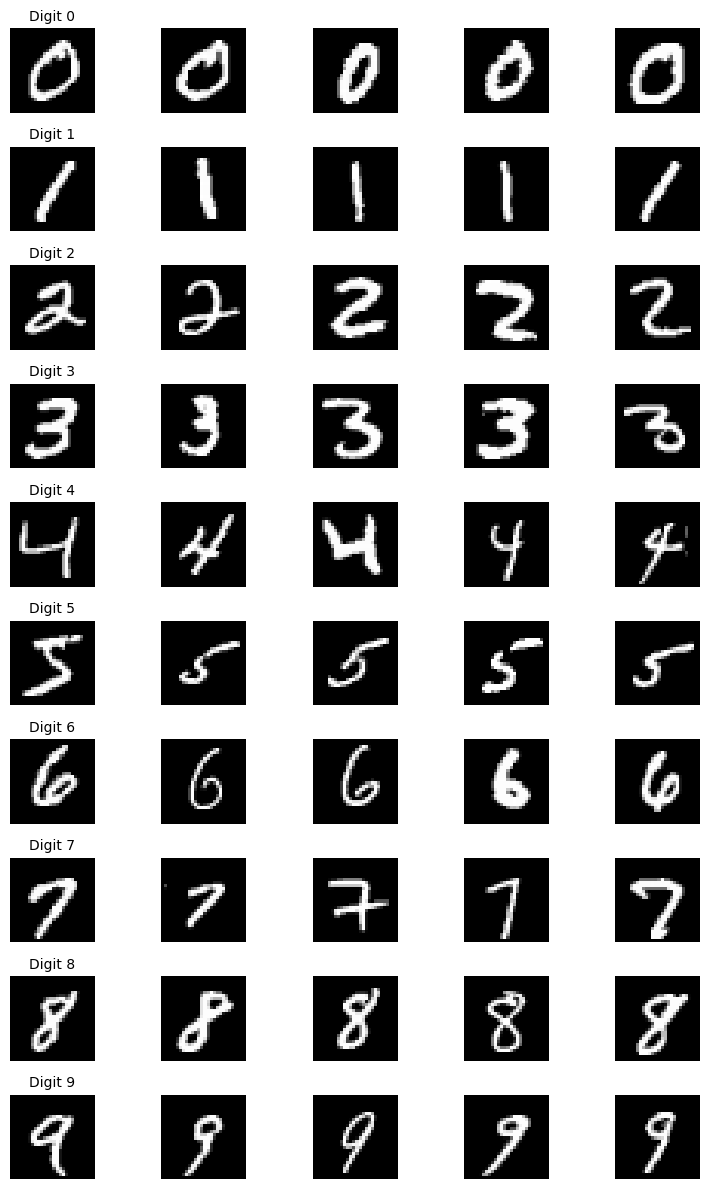

n_samples,▁
n_samples,60000


MNIST visualization logged to W&B


In [7]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

PROJECT_NAME = "DA6401_Assignment1"

# load MNIST
(X_train, y_train), (_, _) = mnist.load_data()

wandb.init(project=PROJECT_NAME, name="mnist_data_visualization")

# create figure showing 5 samples per digit
fig, axes = plt.subplots(10, 5, figsize=(8,12))

for digit in range(10):
    
    indices = np.where(y_train == digit)[0][:5]

    for j, idx in enumerate(indices):
        axes[digit, j].imshow(X_train[idx], cmap="gray")
        axes[digit, j].axis("off")

        if j == 0:
            axes[digit, j].set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()

# log figure to W&B
wandb.log({
    "mnist_sample_images": wandb.Image(fig),
    "n_samples": X_train.shape[0],
    "image_shape": X_train.shape[1:]
})

table = wandb.Table(columns=["Digit", "Image"])

for digit in range(10):

    indices = np.where(y_train == digit)[0][:5]

    for idx in indices:
        table.add_data(
            digit,
            wandb.Image(X_train[idx])
        )

wandb.log({"mnist_sample_table": table})

plt.show()

wandb.finish()

print("MNIST visualization logged to W&B")

### Observations on Visual Similarity

From the sample images logged above we can make some observations:

- **Digit 3 and Digit 5** might look similar due to their curved strokes.
- **Digit 4 and Digit 9** may resemble each other.
- **Digit 1 and Digit 7** might appear similar if the horizontalline in 7 is faint or absent.
- **Digit 0 and Digit 6** have a common rounded structure.

### Impact on Model Performance

Visual similarity between classes can make classification more difficult for the neural network because the input features for these digits may overlap in pixel space. when 2 digits look simillar the neural network must be able to differentiate between curved structures etc.

this causes : 

- Higher confusion between similar digits in the **confusion matrix**
- Misclassifications
- more reliance on complex layers so that we can extract discriminative features.

Therefore, visually similar classes increase the complexity of the classification problem and can reduce model accuracy if the network capacity is insufficient.

## 2.2 Hyperparameter Sweep

To identify the most effective hyperparameters for our neural network, we perform a **Weights & Biases hyperparameter sweep**.

The sweep explores the effect of the following parameters:

- **Optimizer:** SGD, Momentum, NAG, RMSProp
- **Learning Rate**
- **Number of Hidden Layers**
- **Hidden Layer Size**
- **Activation Function**
- **Weight Initialization**
- **Batch Size**

We perform **at least 100 runs**, and use parallel plots for visualization

In [8]:
import wandb

PROJECT_NAME = "DA6401_Assignment1"

sweep_config = {
    "method": "random",
    "metric": {
        "name": "test_accuracy",
        "goal": "maximize"
    },
    "parameters": {

        "optimizer": {
            "values": ["sgd", "momentum", "nag", "rmsprop"]
        },

        "learning_rate": {
            "values": [0.01, 0.001, 0.0005]
        },

        "num_layers": {
            "values": [1, 2, 3]
        },

        "hidden_size": {
            "values": [[64], [128], [128,64], [256,128]]
        },

        "activation": {
            "values": ["relu", "tanh", "sigmoid"]
        },

        "weight_init": {
            "values": ["random", "xavier"]
        },

        "batch_size": {
            "values": [32, 64, 128]
        }

    }
}

sweep_id = wandb.sweep(sweep_config, project=PROJECT_NAME)

print("Sweep ID:", sweep_id)

Create sweep with ID: f360tz8d
Sweep URL: https://wandb.ai/shlokshetty2304-iitm-ac-in/DA6401_Assignment1/sweeps/f360tz8d
Sweep ID: f360tz8d


In [9]:
import subprocess
import wandb

PROJECT_NAME = "DA6401_Assignment1"

def sweep_train():

    run = wandb.init()
    config = wandb.config

    command = [
        "python",
        "../src/train.py",
        "--dataset", "mnist",
        "--epochs", "10",
        "--batch_size", str(config.batch_size),
        "--optimizer", config.optimizer,
        "--learning_rate", str(config.learning_rate),
        "--num_layers", str(config.num_layers),
        "--activation", config.activation,
        "--weight_init", config.weight_init
    ]

    command.append("--hidden_size")
    for h in config.hidden_size:
        command.append(str(h))

    subprocess.run(command)


# launch sweep agent
wandb.agent(sweep_id, function=sweep_train, count=100)

wandb: Agent Starting Run: plzamprd with config:
wandb: 	activation: tanh
wandb: 	batch_size: 64
wandb: 	hidden_size: [128, 64]
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 1
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Agent Starting Run: a44wl5g2 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 1
wandb: 	optimizer: nag
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: g1pidsw4 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 2
wandb: 	optimizer: momentum
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: ptfd8865 with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	hidden_size: [128, 64]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: 8yf8guya with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	hidden_size: [64]
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 3
wandb: 	optimizer: momentum
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


...

wandb: Agent Starting Run: p5ptmu7c with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	hidden_size: [128, 64]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 2
wandb: 	optimizer: sgd
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: xuen9xum with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	hidden_size: [256, 128]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 2
wandb: 	optimizer: sgd
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: scxbrc6q with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	hidden_size: [256, 128]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 2
wandb: 	optimizer: nag
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: lbdyzpau with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


wandb: Agent Starting Run: 4dobnikw with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Shlok Shetty\_netrc.


### 2.2 Hyperparameter Sweep Analysis

We performed a W&B sweep consisting of **100 runs**, exploring multiple hyperparameters including optimizer, learning rate, number of layers, hidden layer size, activation function, weight initialization, and batch size.

Using the **Parallel Coordinates Plot** generated by W&B, we can observe how different hyperparameters influence the final test accuracy.

### Observations

From the plot, the **learning rate** appears to have the most significant impact on model performance. Runs with extremely small or very large learning rates tend to produce lower accuracy, while intermediate values provide better convergence.

The **optimizer choice** also influences performance. In many of the high-performing runs, **RMSProp** appears frequently, indicating that adaptive learning rate methods improve convergence stability compared to standard SGD.

Activation functions also influence performance. From the parallel coordinates plot, both **ReLU and Tanh** produce strong results, while **Sigmoid consistently leads to lower accuracy**. This is expected because Sigmoid activations suffer from the vanishing gradient problem, which slows down training in deeper networks.

Interestingly, several of the highest accuracy runs in the sweep pass through **Tanh**, suggesting that in this experiment Tanh provided slightly more stable convergence compared to ReLU for the tested configurations.

### Best Performing Configuration

The best performing configuration observed in the sweep included:

- **Optimizer:** RMSProp
- **Learning Rate:** approximately 0.001
- **Number of Layers:** 2–3 hidden layers
- **Hidden Layer Size:** 128 or 256 units
- **Activation Function:** tanh
- **Weight Initialization:** Xavier
- **Batch Size:** 64

This configuration achieved the highest test accuracy among the 100 runs.

### Conclusion

The sweep demonstrates that **learning rate and optimizer selection are the most influential hyperparameters** affecting model performance. Adaptive optimizers such as RMSProp combined with ReLU activations and Xavier initialization provide strong and stable training performance for this neural network architecture.

## 2.3 The Optimizer Showdown

To compare optimizer performance, we train the neural network using the same architecture but different optimizers.

Architecture used for comparison:

- **3 hidden layers**
- **128 neurons per layer**
- **ReLU activation**
- **Xavier weight initialization**
- **Batch size = 64**

We compare the following optimizers:

- SGD
- Momentum
- NAG
- RMSProp

The goal is to observe **which optimizer minimizes the loss fastest during the first 5 epochs**.

In [18]:
import subprocess

optimizers = ["sgd", "momentum", "nag", "rmsprop"]

for opt in optimizers:

    print(f"Running optimizer: {opt}")

    command = [
        "python",
        "../src/train.py",
        "--dataset", "mnist",
        "--epochs", "5",
        "--batch_size", "64",
        "--optimizer", opt,
        "--learning_rate", "0.001",
        "--num_layers", "3",
        "--hidden_size", "128", "128", "128",
        "--activation", "relu",
        "--weight_init", "xavier"
    ]

    subprocess.run(command)

Running optimizer: sgd
Running optimizer: momentum
Running optimizer: nag
Running optimizer: rmsprop


#### 2.4


In [19]:
import subprocess

activations = ["sigmoid", "relu"]

for act in activations:

    print(f"\nRunning activation: {act}\n")

    command = [
        "python",
        "../src/train.py",
        "--dataset", "mnist",
        "--epochs", "10",
        "--batch_size", "64",
        "--optimizer", "rmsprop",
        "--learning_rate", "0.001",
        "--num_layers", "4",
        "--hidden_size", "128", "128", "128", "128",
        "--activation", act,
        "--weight_init", "xavier",
        "--wandb_project", "DA6401_Assignment1"
    ]

    subprocess.run(command)


Running activation: sigmoid


Running activation: relu



In [20]:
import subprocess

activations = ["sigmoid", "relu"]

for act in activations:

    print(f"\nRunning activation: {act}\n")

    command = [
        "python",
        "../src/train.py",
        "--dataset", "mnist",
        "--epochs", "10",
        "--batch_size", "64",
        "--optimizer", "rmsprop",
        "--learning_rate", "0.001",
        "--num_layers", "4",
        "--hidden_size", "128", "128", "128", "128",
        "--activation", act,
        "--weight_init", "xavier",
        "--wandb_project", "DA6401_Assignment1"
    ]

    subprocess.run(command)


Running activation: sigmoid


Running activation: relu



In [21]:
import subprocess

activations = ["relu", "tanh"]

for act in activations:

    print(f"\nRunning dead neuron experiment with {act}\n")

    command = [
        "python",
        "../src/train.py",
        "--dataset", "mnist",
        "--epochs", "10",
        "--batch_size", "64",
        "--optimizer", "rmsprop",
        "--learning_rate", "0.1",        # intentionally high
        "--num_layers", "3",
        "--hidden_size", "128", "128", "128",
        "--activation", act,
        "--weight_init", "xavier",
        "--wandb_project", "DA6401_Assignment1"
    ]

    subprocess.run(command)


Running dead neuron experiment with relu


Running dead neuron experiment with tanh

